In [26]:
%pip install pandas matplotlib seaborn numpy

Note: you may need to restart the kernel to use updated packages.


In [27]:
import pandas as pd
import os
import json
import numpy as np

In [28]:
def parse_result_as_df_recommended(result_file):
    with open(result_file, 'r') as f:
        lines = f.readlines()
    json_data = json.loads(('').join(lines))
    
    # Handle evaluationResult array by extracting comprehensive statistics
    if 'evaluationResult' in json_data and isinstance(json_data['evaluationResult'], list):
        eval_results = json_data['evaluationResult']
        
        # Basic statistics
        json_data['evaluationResult_count'] = len(eval_results)

        # Exact matching statistics
        exact_matches = [item for item in eval_results if item.get('doesMatchExactly', False)]
        json_data['evaluationResult_exact_matches'] = len(exact_matches) > 0
        # json_data['evaluationResult_exact_rate'] = len(exact_matches) / len(eval_results) if eval_results else 0
        
        # Syntactic matching statistics
        syntactic_matches = [item for item in eval_results if item.get('doesMatchSyntactically', False)]
        json_data['evaluationResult_syntactic_matches'] = len(syntactic_matches) > 0
        # json_data['evaluationResult_syntactic_rate'] = len(syntactic_matches) / len(eval_results) if eval_results else 0
        
        # Semantic matching statistics
        semantic_matches = [item for item in eval_results if item.get('doesMatchSemantically', False)]
        json_data['evaluationResult_semantic_matches'] = len(semantic_matches) > 0
        json_data['evaluationResult_semantic_match_count'] = len(semantic_matches)
        # json_data['evaluationResult_semantic_rate'] = len(semantic_matches) / len(eval_results) if eval_results else 0
        
        # # Top suggestions
        # json_data['evaluationResult_top_suggestion'] = eval_results[0]['suggestion'] if eval_results else None
        # json_data['evaluationResult_top_rank'] = eval_results[0]['rank'] if eval_results else None
        
        # # Average rank of matches
        # if syntactic_matches:
        #     json_data['evaluationResult_avg_syntactic_rank'] = np.mean([item['rank'] for item in syntactic_matches])
        # else:
        #     json_data['evaluationResult_avg_syntactic_rank'] = None
            
        # Remove the original array to avoid DataFrame creation issues
        del json_data['evaluationResult']

        # Delete any key that starts with 'suggestionIn' to avoid redundancy
        keys_to_delete = [key for key in json_data.keys() if key.startswith('suggestionIn')]
        for key in keys_to_delete:
            del json_data[key]
    
    # Handle any other arrays in similar fashion
    for key, value in list(json_data.items()):
        if isinstance(value, list) and key != 'evaluationResult':  # Handle other potential arrays
            json_data[f'{key}_array_length'] = len(value)
            json_data[f'{key}_as_string'] = json.dumps(value)  # Keep as JSON string if needed
            del json_data[key]  # Remove original array
    
    df = pd.DataFrame(json_data, index=[0])
    return df

In [29]:
# Updated data loading code with proper JSON array handling
GENERATOR_TEST_RESULT_DIR = '../test-results/generator/multi_term/'
FORMULA_TEST_RESULT_DIR = '../test-results/formula/multi_term/'
LLM_TEST_RESULT_DIR = '../test-results/llm/multi_term/'

generator_results_df = pd.DataFrame()
formula_results_df = pd.DataFrame()
llm_results_df = pd.DataFrame()    

print("Loading generator results...")
for root, subdirs, files in os.walk(GENERATOR_TEST_RESULT_DIR):
    for file in files:
        if file.endswith('.result.json'):
            try:
                df = parse_result_as_df_recommended(os.path.join(root, file))
                generator_results_df = pd.concat([generator_results_df, df], axis=0, ignore_index=True)
            except Exception as e:
                print(f"Error processing {file}: {e}")

print(f"Generator results loaded: {len(generator_results_df)} records")

print("Loading formula results...")
for root, subdirs, files in os.walk(FORMULA_TEST_RESULT_DIR):
    for file in files:
        if file.endswith('.result.json'):
            try:
                df = parse_result_as_df_recommended(os.path.join(root, file))
                formula_results_df = pd.concat([formula_results_df, df], axis=0, ignore_index=True)
            except Exception as e:
                print(f"Error processing {file}: {e}")

print(f"Formula results loaded: {len(formula_results_df)} records")

print("Loading LLM results...")
for root, subdirs, files in os.walk(LLM_TEST_RESULT_DIR):
    for file in files:
        if file.endswith('.result.json'):
            try:
                df = parse_result_as_df_recommended(os.path.join(root, file))
                llm_results_df = pd.concat([llm_results_df, df], axis=0, ignore_index=True)
            except Exception as e:
                print(f"Error processing {file}: {e}")

print(f"LLM results loaded: {len(llm_results_df)} records")

Loading generator results...
Generator results loaded: 1814 records
Loading formula results...
Formula results loaded: 2928 records
Loading LLM results...
LLM results loaded: 106 records


In [30]:
generator_results_df

,modelName,filename,offset,term,line,character,incompletionLine,completionList,completionGenerated,suggestionExists,expectedCompletionWord,expectedCompletionLine,elapsedTimeInMs,evaluationResult_count,evaluationResult_exact_matches,evaluationResult_syntactic_matches,evaluationResult_semantic_matches,evaluationResult_semantic_match_count
0,class-diagram,completion/class-diagram-complete.als,343,-,19,17,all c: Class -,"((*ext)-ext), ((^ext)-ext), ((ext.Class).ext),...",True,True,Object,Object | c in Object.^~ext,8.518042,50,True,True,False,0
1,class-diagram,completion/class-diagram-complete.als,136,.,9,12,no Object.,"((*ext)-ext), ((^ext)-ext), ((ext.Class).ext),...",True,True,ext,ext,34.575208,50,True,True,True,26
2,class-diagram,completion/class-diagram-sig.als,56,extends,5,23,one sig Object extends,"((*ext)-ext), ((^ext)-ext), ((ext.Class).ext),...",True,True,Class,Class {},29.833583,49,True,True,False,0
3,class-diagram,completion/class-diagram-complete.als,357,in,19,31,all c: Class - Object | c in,"((*ext)-ext), ((*ext).c), ((^ext)-ext), ((^ext...",True,False,Object,Object.^~ext,8.080458,92,False,False,True,66
4,class-diagram,completion/class-diagram-complete.als,364,.,19,38,all c: Class - Object | c in Object.,"((*ext)-ext), ((*ext).c), ((^ext)-ext), ((^ext...",True,True,^~ext,^~ext,10.006500,92,True,False,True,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1809,git,completion/git-complete.als,14037,-,619,22,index.sp = index.s -,"((*conflict)-conflict), ((*conflict).Blob), ((...",True,True,f,f,72.980167,1235,True,False,False,0
1810,git,completion/git-complete.als,3963,.,198,25,all f : index.s | no (f.,"((*conflict)-conflict), ((*conflict).Blob), ((...",True,False,^parent.samepath&index.s,^parent.samepath & index.s),70.565666,1079,False,False,False,0
1811,git,completion/git-complete.als,2202,&,109,69,"all s : State, n : current.s | invariant[s] im...","((*conflict)-conflict), ((*conflict).Blob), ((...",True,False,n.samepath,(n.samepath-n)),74.834333,1136,False,False,False,0
1812,git,completion/git-complete.als,2083,.,105,74,"all s : State, f : File, ff : f.samepath & Fil...","((*conflict)-conflict), ((*conflict).Blob), ((...",True,True,content,content = ff.content,71.793000,1199,True,False,False,0


In [31]:
formula_results_df

,modelName,filename,offset,term,line,character,incompletionLine,completionList,completionGenerated,suggestionExists,...,expectedCompletionLine,elapsedTimeInMs,preprocessingTime,parsingTime,generationTime,evaluationResult_count,evaluationResult_exact_matches,evaluationResult_syntactic_matches,evaluationResult_semantic_matches,evaluationResult_semantic_match_count
0,class-diagram,completion/class-diagram-complete.als,343,-,19,17,all c: Class -,"*ext.Class, *ext.Class.*ext, *ext.Class.^ext, ...",True,True,...,Object | c in Object.^~ext,11.552583,1,0,6,80,True,False,False,0
1,class-diagram,completion/class-diagram-complete.als,136,.,9,12,no Object.,"*ext.Class, *ext.Object, ^ext.Class, ^ext.Obje...",True,True,...,ext,15.821583,2,1,2,17,True,True,False,0
2,class-diagram,completion/class-diagram-sig.als,56,extends,5,23,one sig Object extends,"Class, Int, String, none, univ",True,True,...,Class {},9.346834,1,0,0,5,True,True,False,0
3,class-diagram,completion/class-diagram-complete.als,357,in,19,31,all c: Class - Object | c in,"*ext.c, *ext.c.*ext, *ext.c.^ext, *ext.c.ext, ...",True,False,...,Object.^~ext,13.611542,1,1,7,107,False,False,False,0
4,class-diagram,completion/class-diagram-complete.als,364,.,19,38,all c: Class - Object | c in Object.,"*ext.c, ^ext.c, ext.c, ~ext.c, *ext.Class, *ex...",True,True,...,^~ext,7.555584,1,0,1,26,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2923,smart-home,completion/smart_home-complete.als,5031,.,156,55,all dev : IndoorDevice | some rum : Room | dev...,"devices.dev, ~room.dev, ~roomsToClean.dev, dev...",True,True,...,devices <=> rum in dev.room,61.524125,16,8,2,100,True,False,False,0
2924,smart-home,completion/smart_home-sig.als,1038,extends,61,17,sig Lock extends,"AC, Barometer, Clean, Clock, Device, Dirty, Di...",True,True,...,IndoorDevice {,3.066500,0,0,0,38,True,True,False,0
2925,smart-home,completion/smart_home-complete.als,1898,in,96,72,fact {all dev : Outlet | some pressure : Press...,"dev, dev.filling, dev.filling.~occupation, dev...",True,True,...,dev.sensors },222.406500,18,8,151,3469,True,False,False,0
2926,smart-home,completion/smart_home-complete.als,2836,in,108,55,fact {all dev : Vacuum | some clock : Clock | ...,"clock, clock, clock.id.~value, clock.value.~id...",True,True,...,dev.sensors },220.379250,17,8,151,3469,True,False,False,0


In [32]:
# results_df['suggestion_state'] = results_df.apply(lambda row: 'no-suggestion' if not row['completionGenerated'] else row['suggestionExists'], axis=1)
generator_results_df['suggestion_state'] = generator_results_df.apply(
    lambda row: 'no-suggestion' if not row['completionGenerated'] else row['suggestionExists'], axis=1)

formula_results_df['suggestion_state'] = formula_results_df.apply(
    lambda row: 'no-suggestion' if not row['completionGenerated'] else row['suggestionExists'], axis=1)

llm_results_df['suggestion_state'] = llm_results_df.apply(
    lambda row: 'no-suggestion' if not row['completionGenerated'] else row['suggestionExists'], axis=1)

In [33]:
import matplotlib.pyplot as plt

In [34]:
# Configure notebook display for wider figures
from IPython.display import HTML, display

# Set CSS to make figures use more width
display(HTML("""
<style>
    .output_png {
        display: block;
        margin: 0 auto;
        max-width: 100% !important;
        width: 100% !important;
    }
    .jp-OutputArea-output {
        overflow-x: auto;
    }
</style>
"""))

# Configure matplotlib backend for better notebook integration
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.max_open_warning'] = 0

In [35]:
# avg_time_per_model = results_df.groupby('modelName')['elapsedTimeInMs'].mean()
# median_time_per_model = results_df.groupby('modelName')['elapsedTimeInMs'].median()
# p99_time_per_model = results_df.groupby('modelName')['elapsedTimeInMs'].quantile(0.99)
# suggestion_count_per_model = results_df.groupby('modelName')['suggestion_state'].value_counts().unstack().fillna(0)

# GENERATOR ANALYSIS
generator_avg_time_per_model = generator_results_df.groupby('modelName')['elapsedTimeInMs'].mean()
generator_median_time_per_model = generator_results_df.groupby('modelName')['elapsedTimeInMs'].median()
generator_p99_time_per_model = generator_results_df.groupby('modelName')['elapsedTimeInMs'].quantile(0.99)
generator_suggestion_count_per_model = generator_results_df.groupby('modelName')['evaluationResult_count'].mean()
generator_suggestion_state_count_per_model = generator_results_df.groupby('modelName')['suggestion_state'].value_counts().unstack().fillna(0)
generator_suggestion_state_count = generator_suggestion_state_count_per_model.sum()

# FORMULA ANALYSIS
formula_avg_time_per_model = formula_results_df.groupby('modelName')['elapsedTimeInMs'].mean()
formula_median_time_per_model = formula_results_df.groupby('modelName')['elapsedTimeInMs'].median()
formula_p99_time_per_model = formula_results_df.groupby('modelName')['elapsedTimeInMs'].quantile(0.99)
formula_suggestion_count_per_model = formula_results_df.groupby('modelName')['evaluationResult_count'].mean()
formula_suggestion_state_count_per_model = formula_results_df.groupby('modelName')['suggestion_state'].value_counts().unstack().fillna(0)
formula_suggestion_state_count = formula_suggestion_state_count_per_model.sum()

# LLM ANALYSIS
llm_avg_time_per_model = llm_results_df.groupby('modelName')['elapsedTimeInMs'].mean()
llm_median_time_per_model = llm_results_df.groupby('modelName')['elapsedTimeInMs'].median()
llm_p99_time_per_model = llm_results_df.groupby('modelName')['elapsedTimeInMs'].quantile(0.99)
llm_suggestion_count_per_model = llm_results_df.groupby('modelName')['evaluationResult_count'].mean()
llm_suggestion_state_count_per_model = llm_results_df.groupby('modelName')['suggestion_state'].value_counts().unstack().fillna(0)
llm_suggestion_state_count = llm_suggestion_state_count_per_model.sum()

# print("Generator suggestion counts per model:")
# print(generator_suggestion_state_count_per_model)

# print("\nFormula suggestion counts per model:")
# print(formula_suggestion_state_count_per_model)

print("\nOverall generator suggestion state counts:")
print(generator_suggestion_state_count)

print("\nOverall formula suggestion state counts:")
print(formula_suggestion_state_count)

print("\nOverall LLM suggestion state counts:")
print(llm_suggestion_state_count)


Overall generator suggestion state counts:
suggestion_state
False             450.0
True             1356.0
no-suggestion       8.0
dtype: float64

Overall formula suggestion state counts:
suggestion_state
False             208.0
True             2532.0
no-suggestion     188.0
dtype: float64

Overall LLM suggestion state counts:
suggestion_state
False    23
True     83
dtype: int64


In [36]:
generator_suggestion_state_count_per_model

suggestion_state,False,True,no-suggestion
modelName,,,
array,0.0,9.0,0.0
bempl,2.0,6.0,0.0
binary-tree,1.0,8.0,0.0
c-tree,3.0,6.0,0.0
class-diagram,1.0,5.0,0.0
classroom,7.0,23.0,0.0
classroom-fol,8.0,30.0,0.0
classroom-rl,5.0,25.0,0.0
courses-v1,17.0,38.0,0.0


In [37]:
formula_suggestion_state_count_per_model

suggestion_state,False,True,no-suggestion
modelName,,,
array,0.0,9.0,0.0
bempl,0.0,8.0,0.0
binary-tree,0.0,9.0,0.0
c-tree,1.0,8.0,0.0
class-diagram,1.0,5.0,0.0
classroom,5.0,25.0,0.0
classroom-fol,3.0,34.0,1.0
classroom-rl,3.0,26.0,1.0
courses-v1,13.0,39.0,3.0


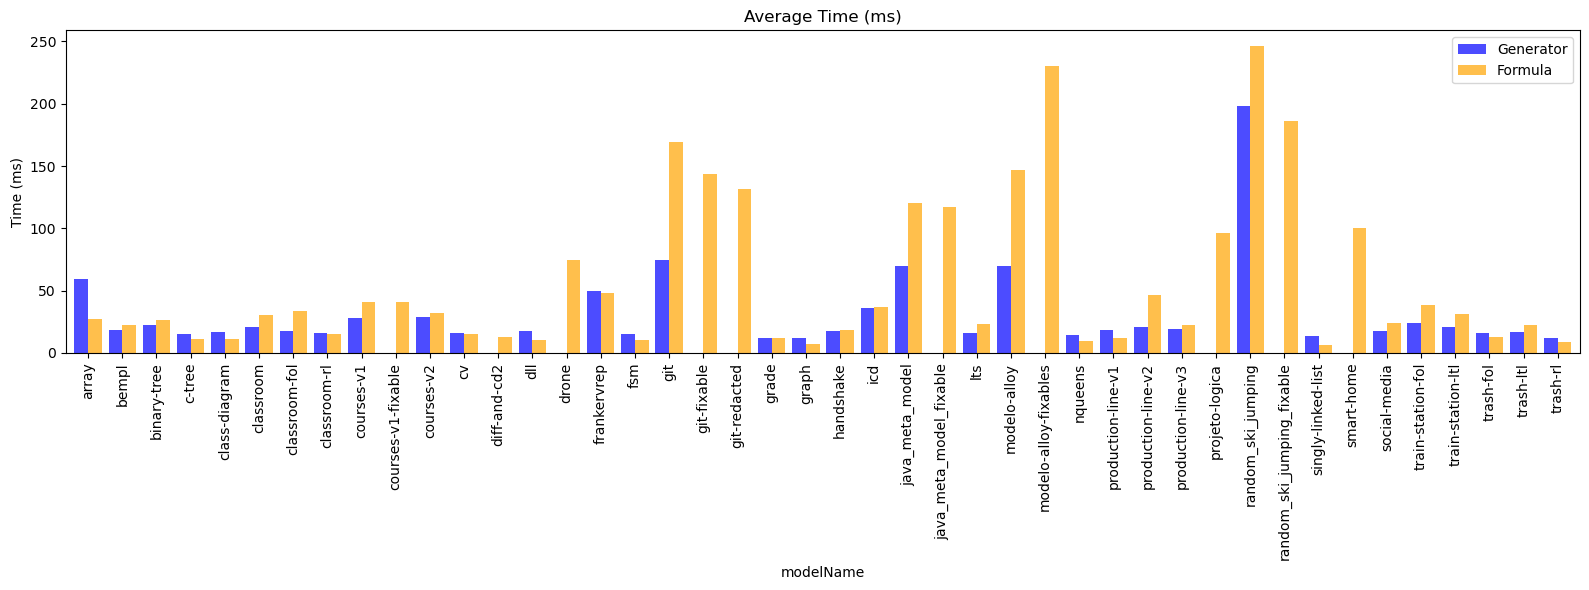

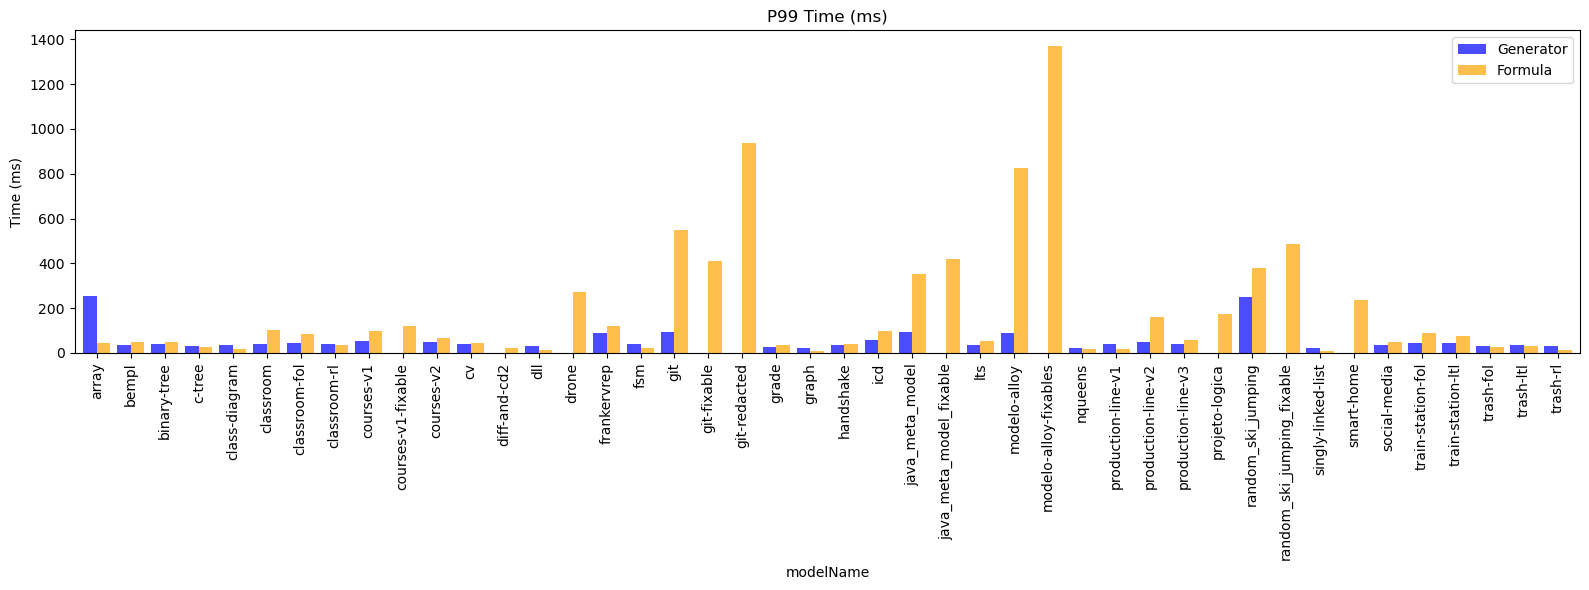

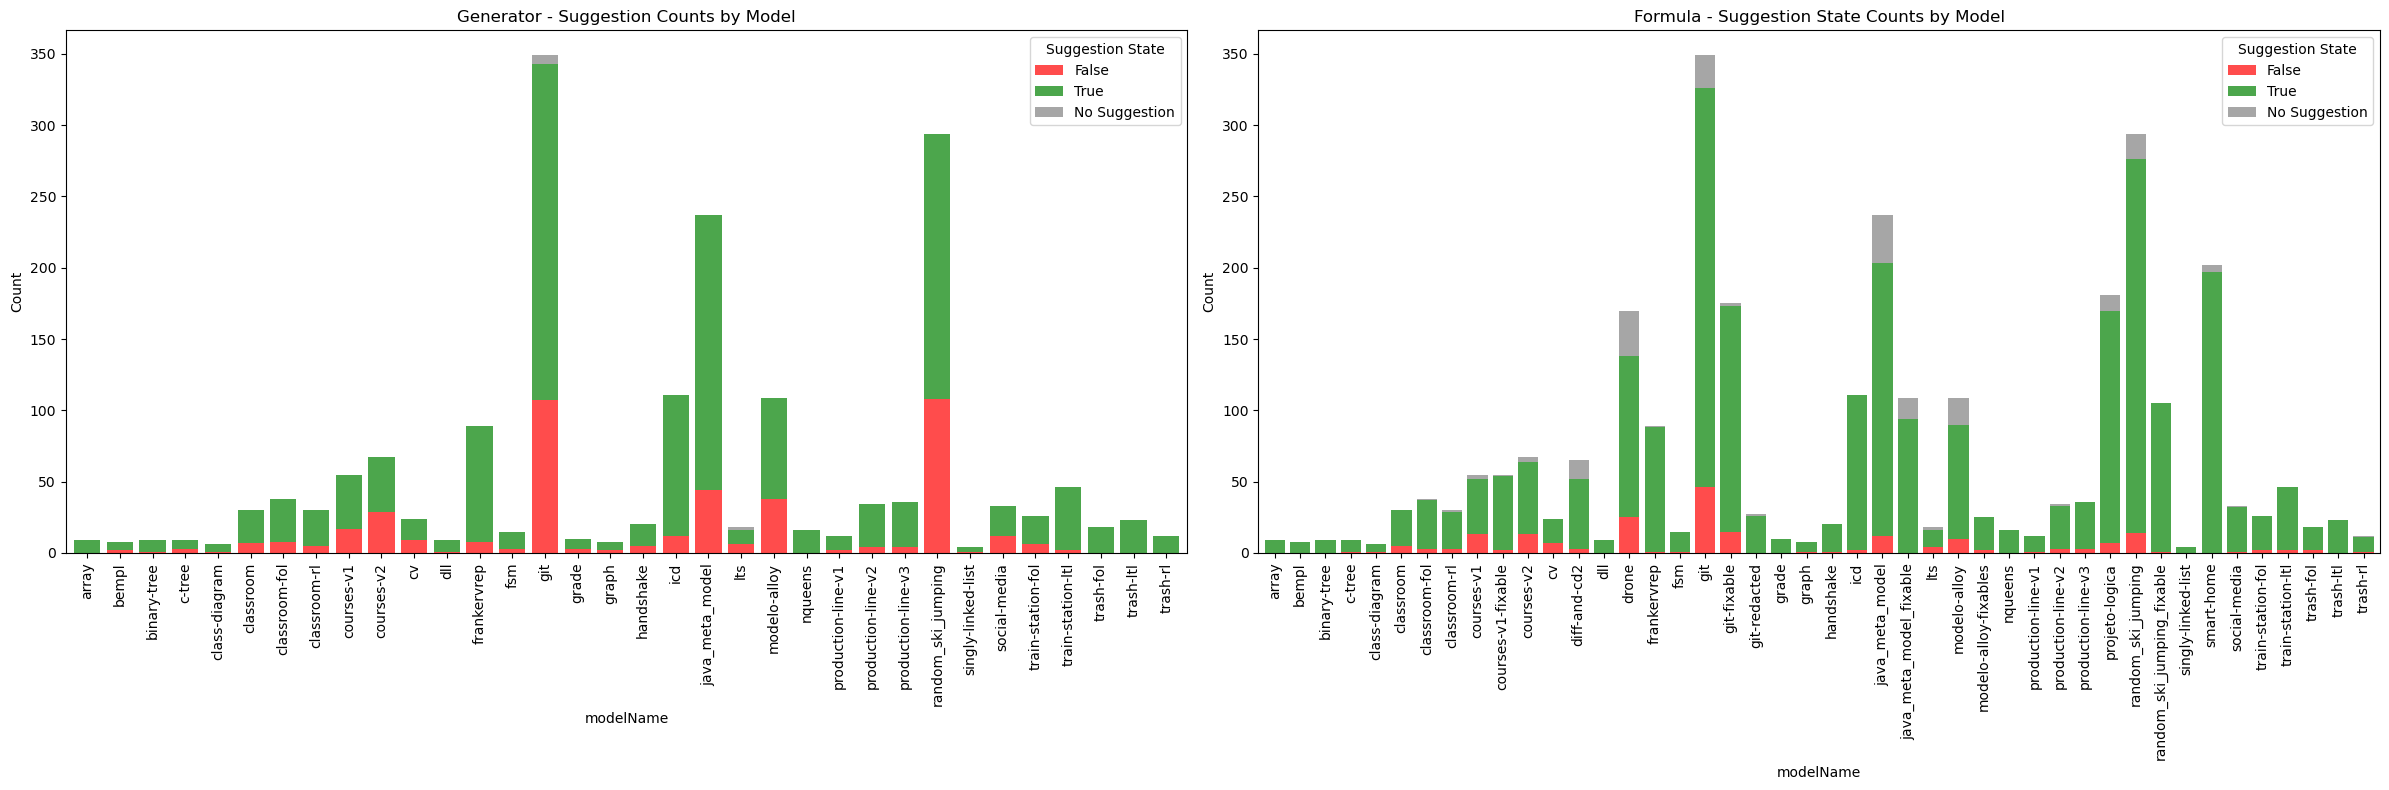

<Figure size 1600x600 with 0 Axes>

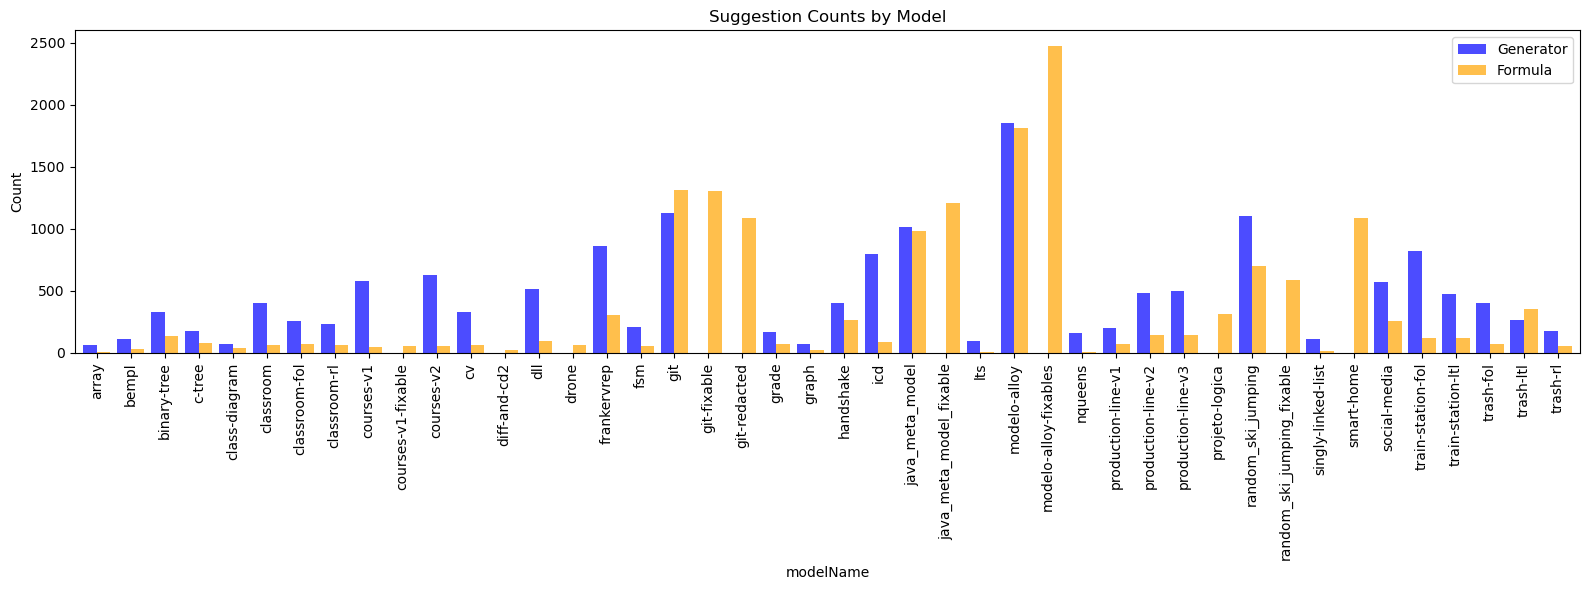

<Figure size 1600x600 with 0 Axes>

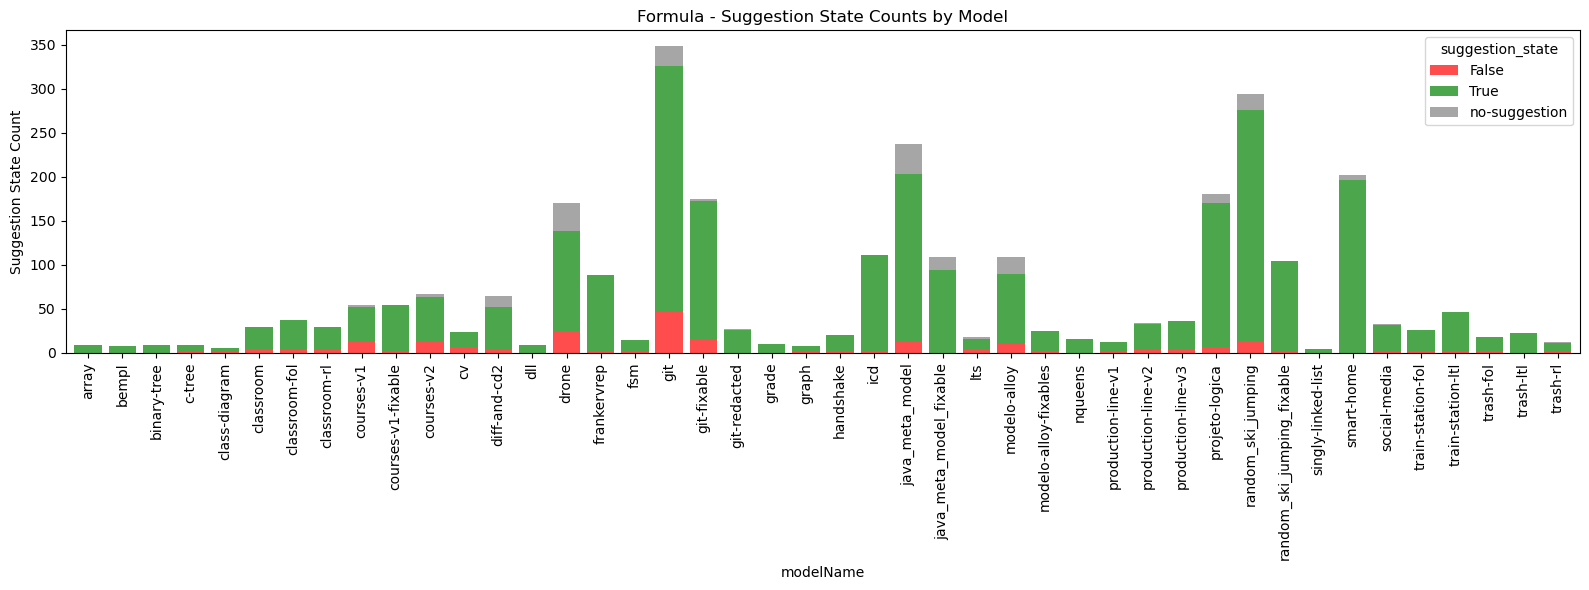

<Figure size 1600x600 with 0 Axes>

In [38]:
# Create 4 separate charts for better visibility
# Configure matplotlib for better notebook display
plt.rcParams['figure.max_open_warning'] = 0
plt.rcParams['figure.figsize'] = [16, 6]  # Set default figure size
plt.rcParams['figure.dpi'] = 100

# Chart 1: Average Time Comparison
fig, ax = plt.subplots(figsize=(16, 6))
avg_time_combined = pd.DataFrame({
    'Generator': generator_avg_time_per_model,
    'Formula': formula_avg_time_per_model,
})
avg_time_combined.plot.bar(ax=ax, title='Average Time (ms)', color=['blue', 'orange'], alpha=0.7, width=0.8)
ax.set_ylabel('Time (ms)')
ax.tick_params(axis='x', rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

# Chart 3: P99 Time Comparison
fig, ax = plt.subplots(figsize=(16, 6))
p99_time_combined = pd.DataFrame({
    'Generator': generator_p99_time_per_model,
    'Formula': formula_p99_time_per_model,
})
p99_time_combined.plot.bar(ax=ax, title='P99 Time (ms)', color=['blue', 'orange'], alpha=0.7, width=0.8)
ax.set_ylabel('Time (ms)')
ax.tick_params(axis='x', rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

# Chart 4: Combined Suggestion Counts as Stacked Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# Generator stacked bar chart
generator_suggestion_state_count_per_model.plot.bar(
    ax=axes[0], 
    stacked=True, 
    title='Generator - Suggestion Counts by Model',
    color=['red', 'green', 'gray'],
    alpha=0.7,
    width=0.8
)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=90)
axes[0].legend(title='Suggestion State', labels=['False', 'True', 'No Suggestion'])

# Formula stacked bar chart
formula_suggestion_state_count_per_model.plot.bar(
    ax=axes[1], 
    stacked=True, 
    title='Formula - Suggestion State Counts by Model',
    color=['red', 'green', 'gray'],
    alpha=0.7,
    width=0.8
)
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend(title='Suggestion State', labels=['False', 'True', 'No Suggestion'])

plt.tight_layout()
plt.show()

# Chart 5: Suggestion Counts by Model
suggestion_counts_combined = pd.DataFrame({
    'Generator': generator_suggestion_count_per_model,
    'Formula': formula_suggestion_count_per_model
})
suggestion_counts_combined = suggestion_counts_combined.fillna(0)  # Fill NaN values with 0 for better plotting 
# Plotting suggestion counts for Generator and Formula
plt.figure(figsize=(16, 6))
suggestion_counts_combined.plot.bar(
    title='Suggestion Counts by Model',
    color=['blue', 'orange'],
    alpha=0.7,
    width=0.8
)
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Formula stacked bar chart singled out for better visibility
plt.figure(figsize=(16, 6))
formula_suggestion_state_count_per_model.plot.bar(
    stacked=True, 
    title='Formula - Suggestion State Counts by Model',
    color=['red', 'green', 'gray'],
    alpha=0.7,
    width=0.8
)
plt.ylabel('Suggestion State Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

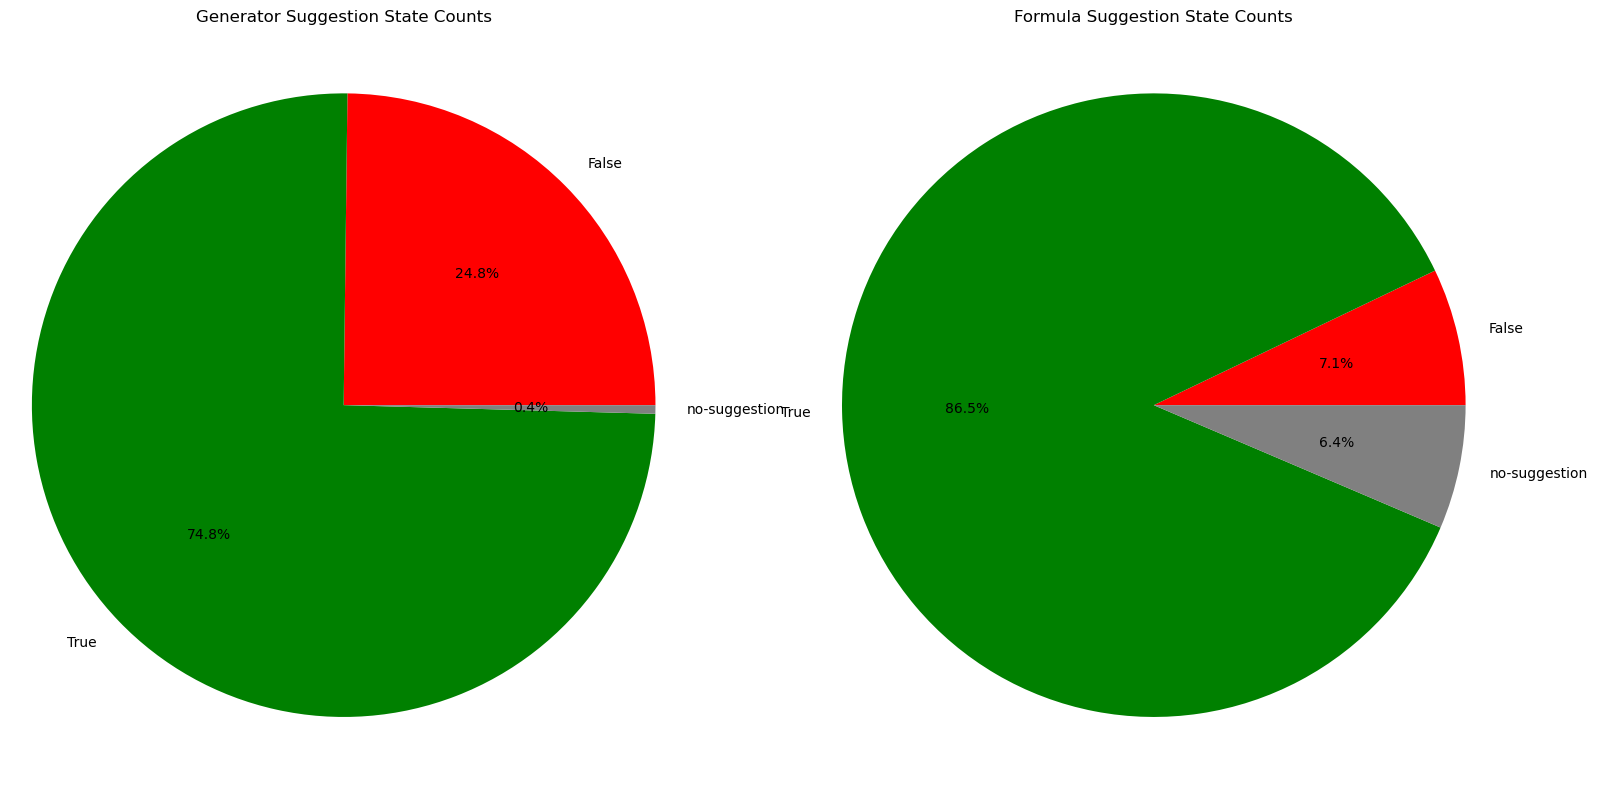

In [39]:
# Pie charts: Generator vs Formula Suggestion State Counts
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Generator pie chart
generator_suggestion_state_count.plot.pie(
    ax=axes[0],
    autopct='%1.1f%%',
    colors=['red', 'green', 'gray'],
    legend=False,
    title='Generator Suggestion State Counts'
)
axes[0].set_ylabel('')
axes[0].set_title('Generator Suggestion State Counts')
axes[0].axis('equal')

# Formula pie chart
formula_suggestion_state_count.plot.pie(
    ax=axes[1],
    autopct='%1.1f%%',
    colors=['red', 'green', 'gray'],
    legend=False,
    title='Formula Suggestion State Counts'
)
axes[1].set_ylabel('')
axes[1].set_title('Formula Suggestion State Counts')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

In [40]:
# Let's examine the suggestion count data to understand the success rates better
print("Generator suggestion counts per model:")
print(generator_suggestion_state_count_per_model)
print("\nFormula suggestion counts per model:")
print(formula_suggestion_state_count_per_model)

# Let's also check the actual suggestion_state values
print("\nGenerator suggestion states:")
print(generator_results_df['suggestion_state'].value_counts())
print("\nFormula suggestion states:")
print(formula_results_df['suggestion_state'].value_counts())

Generator suggestion counts per model:
suggestion_state    False   True  no-suggestion
modelName                                      
array                 0.0    9.0            0.0
bempl                 2.0    6.0            0.0
binary-tree           1.0    8.0            0.0
c-tree                3.0    6.0            0.0
class-diagram         1.0    5.0            0.0
classroom             7.0   23.0            0.0
classroom-fol         8.0   30.0            0.0
classroom-rl          5.0   25.0            0.0
courses-v1           17.0   38.0            0.0
courses-v2           29.0   38.0            0.0
cv                    9.0   15.0            0.0
dll                   1.0    8.0            0.0
frankervrep           8.0   81.0            0.0
fsm                   3.0   12.0            0.0
git                 107.0  236.0            6.0
grade                 3.0    7.0            0.0
graph                 2.0    6.0            0.0
handshake             5.0   15.0            0.0
i

In [41]:
# Join generator and formula results based on modelName and offset
# We'll use a suffix to distinguish columns from each DataFrame

joined_results_df = pd.merge(
    generator_results_df,
    formula_results_df,
    on=['modelName', 'offset', 'filename', 'term', 'line', 'character', 'incompletionLine'],
    how='right',  # Use inner join to only keep records that exist in both
    suffixes=('_generator', '_formula') 
).sort_values('offset').reset_index(drop=True)

joined_results_df.sample(10)

,modelName,filename,offset,term,line,character,incompletionLine,completionList_generator,completionGenerated_generator,suggestionExists_generator,...,elapsedTimeInMs_formula,preprocessingTime,parsingTime,generationTime,evaluationResult_count_formula,evaluationResult_exact_matches_formula,evaluationResult_syntactic_matches_formula,evaluationResult_semantic_matches_formula,evaluationResult_semantic_match_count_formula,suggestion_state_formula
2912,git-fixable,completion/git-complete-fixable.als,13898,.,578,29,all n : Node | n in current.,NaN,NaN,NaN,...,56.930958,12,5,3,178,True,False,False,0,True
1496,java_meta_model,completion/java_meta_model-complete.als,3802,in,163,67,"some c1,c2: Class, m1:c1.methods, m2:c2.method...","((*extend)-extend), ((*extend).Class), ((*exte...",True,False,...,327.024791,25,12,240,5266,True,False,False,0,True
65,binary-tree,completion/binary-tree-2.als,156,+,11,34,all n : Node | n !in n.^(left +,"((*left)-left), ((*left)-right), ((*left).n), ...",True,True,...,49.259458,2,0,38,176,True,False,False,0,True
1754,drone,completion/Drone-complete.als,4705,.,182,25,d.position.X<d.commande.,NaN,NaN,NaN,...,56.064208,NaN,NaN,NaN,25,False,False,False,0,False
508,cv,completion/cv-complete.als,898,.,36,49,"all u : User, disj x,y : u.visible | x not in y.","((ids.Id)-x), ((ids.Id)-y), ((ids.Id).ids), ((...",True,False,...,17.016542,4,1,2,35,False,False,False,0,False
506,cv,completion/cv-complete.als,896,in,36,47,"all u : User, disj x,y : u.visible | x not in","((ids.Id)-x), ((ids.Id)-y), ((ids.Id).ids), ((...",True,False,...,26.949500,2,1,18,243,False,False,False,0,False
260,classroom-rl,completion/classroom-rl-complete.als,437,in,41,10,Class in,"((*Tutors)-Tutors), ((*Tutors).Student), ((*Tu...",True,False,...,21.101500,3,1,9,93,True,True,False,0,True
1037,diff-and-cd2,completion/diff-complete.als,2218,.,80,45,all l: left | all r: l.get[lFName] | l in r.,NaN,NaN,NaN,...,8.876458,2,0,1,21,True,False,False,0,True
2813,modelo-alloy,completion/ModeloAlloy-complete.als,11958,.,463,39,all m: Pet | all p: m.petOf | m in p.,"((*friends)-friends), ((*friends).aggression),...",True,True,...,57.126000,9,4,13,825,True,False,False,0,True
2443,git,completion/git-complete.als,8183,.,388,42,some c : Commit-stored.s | c.tree = Root.,"((*conflict)-conflict), ((*conflict).Blob), ((...",True,False,...,82.812166,25,13,5,255,True,False,False,0,True


In [42]:
joined_results_df.columns

Index(['modelName', 'filename', 'offset', 'term', 'line', 'character',
       'incompletionLine', 'completionList_generator',
       'completionGenerated_generator', 'suggestionExists_generator',
       'expectedCompletionWord_generator', 'expectedCompletionLine_generator',
       'elapsedTimeInMs_generator', 'evaluationResult_count_generator',
       'evaluationResult_exact_matches_generator',
       'evaluationResult_syntactic_matches_generator',
       'evaluationResult_semantic_matches_generator',
       'evaluationResult_semantic_match_count_generator',
       'suggestion_state_generator', 'completionList_formula',
       'completionGenerated_formula', 'suggestionExists_formula',
       'expectedCompletionWord_formula', 'expectedCompletionLine_formula',
       'elapsedTimeInMs_formula', 'preprocessingTime', 'parsingTime',
       'generationTime', 'evaluationResult_count_formula',
       'evaluationResult_exact_matches_formula',
       'evaluationResult_syntactic_matches_formula',


In [43]:
report_df_alt = joined_results_df.groupby(['modelName']).size().reset_index(name='# loc')

# Column Group: fail to generate suggestion
# no_suggestion_generated_df = joined_results_df[(joined_results_df['completionGenerated_generator'] == False) | (joined_results_df['completionGenerated_formula'] == False)]
# no_suggestion_generated_alt = no_suggestion_generated_df[['modelName', 'completionGenerated_generator', 'completionGenerated_formula']].groupby('modelName').sum().reset_index()

# print(no_suggestion_generated_alt)

# report_df_alt = report_df_alt.merge(no_suggestion_generated_alt, on='modelName', how='left')

# Fill NaN values with 0 for counts
# report_df_alt = report_df_alt.fillna(0)

# FAILURE_TO_GENERATE_COLUMN = '# Failure to Generate?'
# report_df_alt = report_df_alt.rename(columns={
#     'completionFailed_generator': (FAILURE_TO_GENERATE_COLUMN, 'Generator'),
#     'completionFailed_formula': (FAILURE_TO_GENERATE_COLUMN, 'Formula')
# })

# Column Group: total number of suggestions generated
total_suggestions_generated_alt = joined_results_df[['modelName', 'evaluationResult_count_generator','evaluationResult_count_formula',]].groupby('modelName').sum().reset_index()
total_suggestions_generated_alt['diff_total_suggestions'] = (total_suggestions_generated_alt['evaluationResult_count_generator'] - total_suggestions_generated_alt['evaluationResult_count_formula']) / total_suggestions_generated_alt['evaluationResult_count_generator'].replace(0, np.nan) * 100

TOTAL_SUGGESTIONS_GENERATED_COLUMN = '# Total Suggestions Generated'
report_df_alt = report_df_alt.merge(total_suggestions_generated_alt, on='modelName', how='left')
report_df_alt = report_df_alt.fillna(0)  # Fill NaN values after each merge
report_df_alt = report_df_alt.rename(columns={
    'evaluationResult_count_generator': (TOTAL_SUGGESTIONS_GENERATED_COLUMN, 'Generator'),
    'evaluationResult_count_formula': (TOTAL_SUGGESTIONS_GENERATED_COLUMN, 'Formula'),
    'diff_total_suggestions': (TOTAL_SUGGESTIONS_GENERATED_COLUMN, 'Reduction %')
})

# Column Group: Average number of suggestions over location
total_suggestions_generated_alt['avg_suggestion_per_loc_generator'] = total_suggestions_generated_alt['evaluationResult_count_generator'] / report_df_alt['# loc'].replace(0, np.nan)
total_suggestions_generated_alt['avg_suggestion_per_loc_formula'] = total_suggestions_generated_alt['evaluationResult_count_formula'] / report_df_alt['# loc'].replace(0, np.nan)
total_suggestions_generated_alt['diff_avg_suggestions'] = (total_suggestions_generated_alt['avg_suggestion_per_loc_generator'] - total_suggestions_generated_alt['avg_suggestion_per_loc_formula']) / total_suggestions_generated_alt['avg_suggestion_per_loc_generator'].replace(0, np.nan) * 100

avg_suggestion_per_location = total_suggestions_generated_alt[['modelName', 'avg_suggestion_per_loc_generator', 'avg_suggestion_per_loc_formula', 'diff_avg_suggestions']]

AVG_SUGGESTIONS_PER_LOC_COLUMN = 'Avg Suggestions per loc'
report_df_alt = report_df_alt.merge(avg_suggestion_per_location, on='modelName', how='left')
report_df_alt = report_df_alt.fillna(0)  # Fill NaN values after each merge
report_df_alt = report_df_alt.rename(columns={
    'avg_suggestion_per_loc_generator': (AVG_SUGGESTIONS_PER_LOC_COLUMN, 'Generator'),
    'avg_suggestion_per_loc_formula': (AVG_SUGGESTIONS_PER_LOC_COLUMN, 'Formula'),
    'diff_avg_suggestions': (AVG_SUGGESTIONS_PER_LOC_COLUMN, 'Reduction %')
})

# Column Group: Average time taken
avg_time_taken_alt = joined_results_df[['modelName', 'elapsedTimeInMs_generator', 'elapsedTimeInMs_formula']].groupby('modelName').mean().reset_index()
avg_time_taken_alt['diff_in_mean_time'] = (avg_time_taken_alt['elapsedTimeInMs_generator'] - avg_time_taken_alt['elapsedTimeInMs_formula'])
AVG_TIME_TAKEN_COLUMN = 'Avg Time Taken (ms)'
report_df_alt = report_df_alt.merge(avg_time_taken_alt, on='modelName', how='left')
# Note: Don't fill NaN for time averages as 0 would be misleading
report_df_alt = report_df_alt.rename(columns={
    'elapsedTimeInMs_generator': (AVG_TIME_TAKEN_COLUMN, 'Generator'),
    'elapsedTimeInMs_formula': (AVG_TIME_TAKEN_COLUMN, 'Formula'),
    'diff_in_mean_time': (AVG_TIME_TAKEN_COLUMN, 'Reduction')
})

# Column Group: Count of exact matches
count_of_exact_matches_alt = joined_results_df[['modelName', 'evaluationResult_exact_matches_generator', 'evaluationResult_exact_matches_formula']].groupby('modelName').sum().reset_index()

COUNT_OF_EXACT_MATCHES_COLUMN = '# Exact Matches'
report_df_alt = report_df_alt.merge(count_of_exact_matches_alt, on='modelName', how='left')
report_df_alt = report_df_alt.fillna(0)  # Fill NaN values for counts
report_df_alt = report_df_alt.rename(columns={
    'evaluationResult_exact_matches_generator': (COUNT_OF_EXACT_MATCHES_COLUMN, 'Generator'),
    'evaluationResult_exact_matches_formula': (COUNT_OF_EXACT_MATCHES_COLUMN, 'Formula')
})

# Column Group: Syntactic matches
count_of_syntactic_matches_alt = joined_results_df[['modelName', 'evaluationResult_syntactic_matches_generator', 'evaluationResult_syntactic_matches_formula']].groupby('modelName').sum().reset_index()
report_df_alt = report_df_alt.merge(count_of_syntactic_matches_alt, on='modelName', how='left')
report_df_alt = report_df_alt.fillna(0)  # Fill NaN values for counts
COUNT_OF_SYNTACTIC_MATCHES_COLUMN = '# Syntactic Matches'
report_df_alt = report_df_alt.rename(columns={
    'evaluationResult_syntactic_matches_generator': (COUNT_OF_SYNTACTIC_MATCHES_COLUMN, 'Generator'),
    'evaluationResult_syntactic_matches_formula': (COUNT_OF_SYNTACTIC_MATCHES_COLUMN, 'Formula')
})

# Column Group: Semantic matches
# Note: This part is not included in the original code, but if needed, it can be added similarly
count_of_semantic_matches_alt = joined_results_df[['modelName', 'evaluationResult_semantic_matches_generator', 'evaluationResult_semantic_matches_formula']].groupby('modelName').sum().reset_index()
report_df_alt = report_df_alt.merge(count_of_semantic_matches_alt, on='modelName', how='left')
report_df_alt = report_df_alt.fillna(0)  # Fill NaN values for counts
COUNT_OF_SEMANTIC_MATCHES_COLUMN = '# Loc with Semantic Matches'
report_df_alt = report_df_alt.rename(columns={
    'evaluationResult_semantic_matches_generator': (COUNT_OF_SEMANTIC_MATCHES_COLUMN, 'Generator'),
    'evaluationResult_semantic_matches_formula': (COUNT_OF_SEMANTIC_MATCHES_COLUMN, 'Formula')
})

# Column Group: Total Semantic Matches
count_of_total_semantic_matches_alt = joined_results_df[['modelName', 'evaluationResult_semantic_match_count_generator', 'evaluationResult_semantic_match_count_formula']].groupby('modelName').sum().reset_index()
report_df_alt = report_df_alt.merge(count_of_total_semantic_matches_alt, on='modelName', how='left')
report_df_alt = report_df_alt.fillna(0)  # Fill NaN values for counts
COUNT_OF_TOTAL_SEMANTIC_MATCHES_COLUMN = '# Total Semantic Matches'
report_df_alt = report_df_alt.rename(columns={
    'evaluationResult_semantic_match_count_generator': (COUNT_OF_TOTAL_SEMANTIC_MATCHES_COLUMN, 'Generator'),
    'evaluationResult_semantic_match_count_formula': (COUNT_OF_TOTAL_SEMANTIC_MATCHES_COLUMN, 'Formula')
})

# Create the multi-level column index
report_df_alt.columns = pd.MultiIndex.from_tuples([
    ('', 'modelName'),
    ('', '# loc'),
    # (FAILURE_TO_GENERATE_COLUMN, 'Generator'),
    # (FAILURE_TO_GENERATE_COLUMN, 'Formula'),
    (TOTAL_SUGGESTIONS_GENERATED_COLUMN, 'Generator'),
    (TOTAL_SUGGESTIONS_GENERATED_COLUMN, 'Formula'),
    (TOTAL_SUGGESTIONS_GENERATED_COLUMN, 'Reduction %'),

    (AVG_SUGGESTIONS_PER_LOC_COLUMN, 'Generator'),
    (AVG_SUGGESTIONS_PER_LOC_COLUMN, 'Formula'),
    (AVG_SUGGESTIONS_PER_LOC_COLUMN, 'Reduction %'),

    (AVG_TIME_TAKEN_COLUMN, 'Generator'),
    (AVG_TIME_TAKEN_COLUMN, 'Formula'),
    (AVG_TIME_TAKEN_COLUMN, 'Reduction'),

    (COUNT_OF_EXACT_MATCHES_COLUMN, 'Generator'),
    (COUNT_OF_EXACT_MATCHES_COLUMN, 'Formula'),
    (COUNT_OF_SYNTACTIC_MATCHES_COLUMN, 'Generator'),
    (COUNT_OF_SYNTACTIC_MATCHES_COLUMN, 'Formula'),
    (COUNT_OF_SEMANTIC_MATCHES_COLUMN, 'Generator'),
    (COUNT_OF_SEMANTIC_MATCHES_COLUMN, 'Formula'),
    (COUNT_OF_TOTAL_SEMANTIC_MATCHES_COLUMN, 'Generator'),
    (COUNT_OF_TOTAL_SEMANTIC_MATCHES_COLUMN, 'Formula')
])

# Final cleanup: Fill any remaining NaN values
# For count columns, use 0; for time columns, keep NaN (as 0 would be misleading)
numeric_cols = report_df_alt.select_dtypes(include=[np.number]).columns
count_cols = [col for col in numeric_cols if 'time' not in str(col).lower()]

# Apply fillna(0) only to count columns, not time columns
for col in count_cols:
    if col != ('', '# loc'):  # Don't fill the location count as it should always have values
        report_df_alt[col] = report_df_alt[col].fillna(0)

# Format all floating point numbers to 2 decimal places (except for integer columns)
for col in report_df_alt.columns:
    if pd.api.types.is_float_dtype(report_df_alt[col]):
        report_df_alt[col] = report_df_alt[col].round(2)

report_df_alt

/var/folders/54/q9n7_qgd4_98z8qr8wmt28fh0000gs/T/ipykernel_77282/567218049.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  report_df_alt = report_df_alt.fillna(0)  # Fill NaN values for counts
/var/folders/54/q9n7_qgd4_98z8qr8wmt28fh0000gs/T/ipykernel_77282/567218049.py:75: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  report_df_alt = report_df_alt.fillna(0)  # Fill NaN values for counts
/var/folders/54/q9n7_qgd4_98z8qr8wmt28fh0000gs/T/ipykernel_77282/567218049.py:86: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is depre

# Total Suggestions Generated          \
                     modelName # loc                     Generator Formula   
0                        array     9                         546.0      67   
1                        bempl     8                         887.0     283   
2                  binary-tree     9                        2970.0    1264   
3                       c-tree     9                        1589.0     697   
4                class-diagram     6                         425.0     261   
5                    classroom    30                       11988.0    1957   
6                classroom-fol    38                        9821.0    2627   
7                 classroom-rl    30                        6907.0    1990   
8                   courses-v1    55                        8568.0    2600   
9           courses-v1-fixable    55                           0.0    3048   
10                  courses-v2    67                       42101.0    3679   
11                          cv    24                        7923.0    1498   
12                diff-and-cd2    65                           0.0    1614   
13                         dll     9                        4614.0     838   
14                       drone   170                           0.0   11563   
15                 frankervrep    89                       76621.0   26944   
16                         fsm    15                        3096.0     843   
17                         git   349                      393801.0  458731   
18                 git-fixable   175                           0.0  228364   
19                git-redacted    27                           0.0   29264   
20                       grade    10                        1710.0     746   
21                       graph     8                         602.0     175   
22                   handshake    20                        7989.0    5250   
23                         icd   111                       88094.0   10038   
24             java_meta_model   237                      240357.0  233275   
25     java_meta_model_fixable   109                           0.0  132120   
26                         lts    18                        1721.0     204   
27                modelo-alloy   109                      202014.0  197376   
28       modelo-alloy-fixables    25                           0.0   61900   
29                     nqueens    16                        2632.0     152   
30          production-line-v1    12                        2383.0     856   
31          production-line-v2    34                       16474.0    4816   
32          production-line-v3    36                       17848.0    5261   
33              projeto-logica   181                           0.0   56130   
34          random_ski_jumping   294                      323698.0  206249   
35  random_ski_jumping_fixable   105                           0.0   61514   
36          singly-linked-list     4                         455.0      71   
37                  smart-home   202                           0.0  219013   
38                social-media    33                       18976.0    8445   
39           train-station-fol    26                       21390.0    3109   
40           train-station-ltl    46                       21805.0    5540   
41                   trash-fol    18                        7287.0    1267   
42                   trash-ltl    23                        6046.0    8217   
43                    trash-rl    12                        2112.0     630   

               Avg Suggestions per loc                       \
   Reduction %               Generator  Formula Reduction %   
0        87.73                   60.67     7.44       87.73   
1        68.09                  110.88    35.38       68.09   
2        57.44                  330.00   140.44       57.44   
3        56.14                  176.56    77.44       56.14   
4        38.59                   70.83    43.50       38.59   
5      

In [44]:
report_df_alt.to_csv('completion_performance.tsv', index=False, sep='\t')

In [45]:
LARGE_MODELS = ["git", "icd", "frankervrep", "java_meta_model", "random_ski_jumping", "modelo-alloy"]
large_models_report_df = report_df_alt[report_df_alt[('', 'modelName')].isin(LARGE_MODELS)].reset_index(drop=True)
large_models_report_df.sort_values(('', '# loc'))

# Total Suggestions Generated                      \
            modelName # loc                     Generator Formula Reduction %   
0         frankervrep    89                       76621.0   26944       64.83   
4        modelo-alloy   109                      202014.0  197376        2.30   
2                 icd   111                       88094.0   10038       88.61   
3     java_meta_model   237                      240357.0  233275        2.95   
5  random_ski_jumping   294                      323698.0  206249       36.28   
1                 git   349                      393801.0  458731      -16.49   

  Avg Suggestions per loc                      Avg Time Taken (ms)          \
                Generator  Formula Reduction %           Generator Formula   
0                  860.91   302.74       64.83               49.50   47.76   
4                 1853.34  1810.79        2.30               69.41  146.54   
2                  793.64    90.43       88.61               36.24   36.78   
3                 1014.16   984.28        2.95               70.12  120.06   
5                 1101.01   701.53       36.28              198.59  246.60   
1                 1128.37  1314.42      -16.49               74.49  169.17   

            # Exact Matches         # Syntactic Matches          \
  Reduction       Generator Formula           Generator Formula   
0      1.74              71      87                  66      66   
4    -77.13              70      80                  18      10   
2     -0.55              99     109                  10      10   
3    -49.95             190     191                  32      27   
5    -48.01             186     262                  21      16   
1    -94.68             236     280                  13      12   

  # Loc with Semantic Matches         # Total Semantic Matches          
                    Generator Formula                Generator Formula  
0                           0       0                      0.0       0  
4                           0       0                      0.0       0  
2                           0       0                      0.0       0  
3                           0       0                      0.0       0  
5                           0       0                      0.0       0  
1                           0       0                      0.0       0

In [46]:
large_models_report_df.to_csv('completion_performance_large_models.tsv', index=False, sep='\t')

In [47]:
# Separate headers and data
headers = [
    "model",
    "sig",
    "abs",
    "ext",
    "relation",
    "arity",
]

model_sizes = [
    ["array", 2, 0, 0, 2, 2.5],
    ["bempl", 6, 1, 3, 3, 2.0],
    ["binary-tree", 2, 0, 0, 4, 2.0],
    ["c-tree", 4, 1, 2, 2, 2.0],
    ["class-diagram", 2, 0, 1, 1, 2.0],
    ["classroom", 5, 0, 2, 3, 2.33],
    ["classroom-fol", 5, 0, 2, 3, 2.33],
    ["classroom-rl", 5, 0, 2, 3, 2.33],
    ["courses-v1", 6, 0, 2, 5, 2.2],
    ["courses-v2", 6, 0, 2, 5, 2.2],
    ["cv", 5, 1, 2, 4, 2.0],
    ["dll", 2, 0, 0, 4, 2.0],
    ["fsm", 2, 0, 0, 3, 2.0],
    ["graph", 1, 0, 0, 1, 2.0],
    ["grade", 5, 0, 2, 4, 2.0],
    ["handshake", 3, 0, 2, 2, 2.0],
    ["lts", 3, 0, 1, 1, 3.0],
    ["nqueens", 1, 0, 0, 2, 2.0],
    ["production-line-v1", 5, 0, 2, 3, 2.0],
    ["production-line-v2", 10, 1, 7, 4, 2.0],
    ["production-line-v3", 10, 1, 7, 4, 2.0],
    ["singly-linked-list", 2, 0, 0, 2, 2.0],
    ["social-media", 5, 0, 2, 5, 2.0],
    ["trash-fol & rl", 3, 0, 2, 1, 2.0],
    ["trash-rl", 3, 0, 2, 1, 2.0],
    ["trash-ltl", 3, 0, 2, 1, 2.0],
    ["diff-and-cd2", 16, 4, 12, 1, 3.0],
    ["frankervrep", 51, 16, 35, 15, 2.1],
    ["git", 10, 2, 6, 17, 2.3],
    ["icd", 18, 4, 11, 10, 2.0],
    ["smart-home", 34, 7, 27, 17, 2.0],
    ["statecoverage", 67, 3, 61, 10, 2.0],
    ["java_meta_model", 26, 0, 0, 21, 2.0],
    ["random_ski_jumping", 26, 0, 0, 20, 2.0],
    ["modelo-alloy", 42, 0, 0, 31, 2.0]
]

model_size_df = (
    pd.DataFrame(model_sizes, columns=headers)
    .sort_values("model")
    .reset_index(drop=True)
)

model_size_df.sort_values("sig")

,model,sig,abs,ext,relation,arity
17,graph,1,0,0,1,2.00
23,nqueens,1,0,0,2,2.00
28,singly-linked-list,2,0,0,2,2.00
14,fsm,2,0,0,3,2.00
12,dll,2,0,0,4,2.00
0,array,2,0,0,2,2.50
2,binary-tree,2,0,0,4,2.00
4,class-diagram,2,0,1,1,2.00
34,trash-rl,3,0,2,1,2.00
32,trash-fol & rl,3,0,2,1,2.00


In [48]:
loc_count_df = formula_results_df.groupby('modelName').size().reset_index(name='loc_count')

model_size_and_runtime_df = pd.merge(model_size_df, loc_count_df, left_on=('model'), right_on=('modelName'))
model_size_and_runtime_df = pd.merge(model_size_and_runtime_df, formula_avg_time_per_model, left_on=('model'), right_on=('modelName'))

model_size_and_runtime_df.sort_values("loc_count")

,model,sig,abs,ext,relation,arity,modelName,loc_count,elapsedTimeInMs
28,singly-linked-list,2,0,0,2,2.00,singly-linked-list,4,6.076500
4,class-diagram,2,0,1,1,2.00,class-diagram,6,10.974000
1,bempl,6,1,3,3,2.00,bempl,8,22.266349
17,graph,1,0,0,1,2.00,graph,8,7.044573
0,array,2,0,0,2,2.50,array,9,26.992606
2,binary-tree,2,0,0,4,2.00,binary-tree,9,26.265958
3,c-tree,4,1,2,2,2.00,c-tree,9,11.272204
12,dll,2,0,0,4,2.00,dll,9,10.670032
16,grade,5,0,2,4,2.00,grade,10,12.329792
32,trash-rl,3,0,2,1,2.00,trash-rl,12,8.780427


In [49]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [50]:
df_rt = model_size_and_runtime_df.copy()
# Reuse the dataframe computed in the previous cell if present; otherwise reconstruct it quickly.
try:
    _df_corr_src = df_rt.copy()
except NameError:
    _df_corr_src = model_size_and_runtime_df.copy()
    for c in ["sig", "abs", "ext", "relation", "arity", "loc_count", "elapsedTimeInMs"]:
        if c in _df_corr_src.columns:
            _df_corr_src[c] = pd.to_numeric(_df_corr_src[c], errors="coerce")

# Ensure derived metrics exist (works for both paths)
if "sig_abs_ext" not in _df_corr_src.columns:
    _df_corr_src["sig_abs_ext"] = _df_corr_src[["sig", "abs", "ext"]].sum(axis=1)

if "sig_minus_ext_over_sig" not in _df_corr_src.columns:
    _df_corr_src["sig_minus_ext_over_sig"] = (_df_corr_src["sig"] - _df_corr_src["ext"]).div(
        _df_corr_src["sig"].replace(0, np.nan)
    )

if "sig_plus_relation" not in _df_corr_src.columns:
    _df_corr_src["sig_plus_relation"] = _df_corr_src["sig"] + _df_corr_src["relation"]

if "sig_times_relation" not in _df_corr_src.columns:
    _df_corr_src["sig_times_relation"] = _df_corr_src["sig"] * _df_corr_src["relation"]

if "rel_arity_sae" not in _df_corr_src.columns:
    _df_corr_src["rel_arity_sae"] = (
        _df_corr_src["relation"] * _df_corr_src["arity"] * _df_corr_src["sig_abs_ext"]
    )

runtime_col = "elapsedTimeInMs"
metric_cols = {
    "sig": "sig",
    "(sig+abs+ext)": "sig_abs_ext",
    "(sig - ext)/sig": "sig_minus_ext_over_sig",
    "sig + relation": "sig_plus_relation",
    "sig * relation": "sig_times_relation",
    "relation": "relation",
    "arity": "arity",
    "loc_count": "loc_count",
    "relation * arity * (sig+abs+ext)": "rel_arity_sae",
}

rows = []
for label, col in metric_cols.items():
    tmp = _df_corr_src[[runtime_col, col]].dropna()
    n = len(tmp)
    pearson = tmp[runtime_col].corr(tmp[col], method="pearson") if n >= 2 else float("nan")
    spearman = tmp[runtime_col].corr(tmp[col], method="spearman") if n >= 2 else float("nan")
    rows.append({
        "metric": label,
        "n": n,
        "pearson_r": pearson,
        "spearman_r": spearman,
    })

corr_df = pd.DataFrame(rows).sort_values("pearson_r", ascending=False).reset_index(drop=True)

# Pretty display (hide index column)
corr_df.style.hide(axis="index").format({"pearson_r": "{:.4f}", "spearman_r": "{:.4f}"})

metric,n,pearson_r,spearman_r
loc_count,33,0.9043,0.8089
relation,33,0.8506,0.7448
sig + relation,33,0.7216,0.7640
sig * relation,33,0.6762,0.7800
sig,33,0.6005,0.7619
relation * arity * (sig+abs+ext),33,0.5659,0.7911
(sig+abs+ext),33,0.4024,0.7155
(sig - ext)/sig,33,0.1431,-0.1244
arity,33,-0.0736,0.2751
